# Lab Instructions

You have been hired by a record executive to design a guaranteed smash hit song based on data.  The exec has decided that if you make a song that has all the most popular features of recent songs then it will definitely be a hit.  So if - for example - the most common key in the Spotify data is C# then we would want the song we are designing to also be in C#.  If a "typical" value of BPM is between 120 and 130 then we would want the song we are designing to also have a tempo between 120 and 130 BMP.

Visualize and describe the distribution of:
* BPM
* Key
* Mode
* Danceability
* Energy
* Speechiness
* Acousticness

Based on your visualizations and calculations, what values for each of these features would make a song a guaranteed smash hit?  For quantitative features, you should propose a range of values.

Use a large language model to help you write code to identify if there are any songs in the Spotify dataset that meet all of the criteria we determined.  What is/are the artist(s) and title(s) of the song?  Were any of these songs actually popular?

Pick a song that you know was a smash hit. How do the values of BPM, key, mode, danceability, etc. compare to other songs? 

**Hint:**  Import the Spotify data using `df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')`.

In [1]:
import pandas as pd

df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')

<Axes: title={'center': 'Top 10 Most Frequent Artists'}, xlabel='artist(s)_name', ylabel='Number of Hit Songs'>

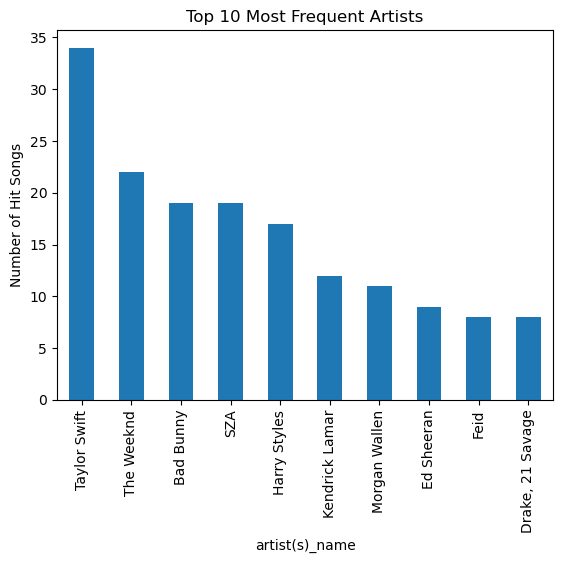

In [2]:
df['artist(s)_name'].value_counts().head(10).plot(kind='bar', title='Top 10 Most Frequent Artists', ylabel='Number of Hit Songs')

<Axes: title={'center': 'Distribution of Mode'}>

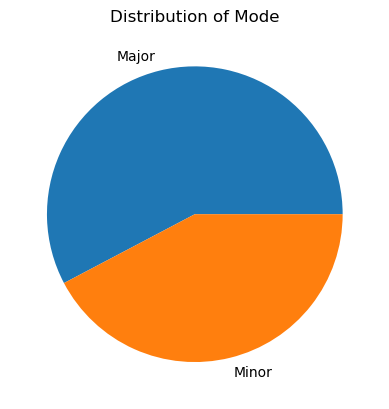

In [3]:
df['mode'].value_counts().plot(kind='pie', title='Distribution of Mode', ylabel='')

<Axes: title={'center': 'Distribution of Key'}, xlabel='Key', ylabel='Count'>

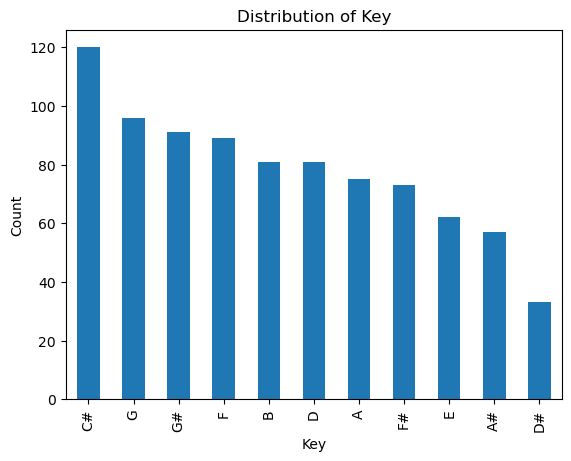

In [10]:
df['key'].value_counts().plot(kind='bar', title='Distribution of Key', xlabel='Key', ylabel='Count')

quant_features = ['bpm', 'danceability_%', 'energy_%', 'speechiness_%', 'acousticness_%']
df[quant_features].hist(figsize=(10, 8), bins=20)

array([[<Axes: title={'center': 'bpm'}>,
        <Axes: title={'center': 'danceability_%'}>],
       [<Axes: title={'center': 'energy_%'}>,
        <Axes: title={'center': 'speechiness_%'}>],
       [<Axes: title={'center': 'acousticness_%'}>, <Axes: >]],
      dtype=object)

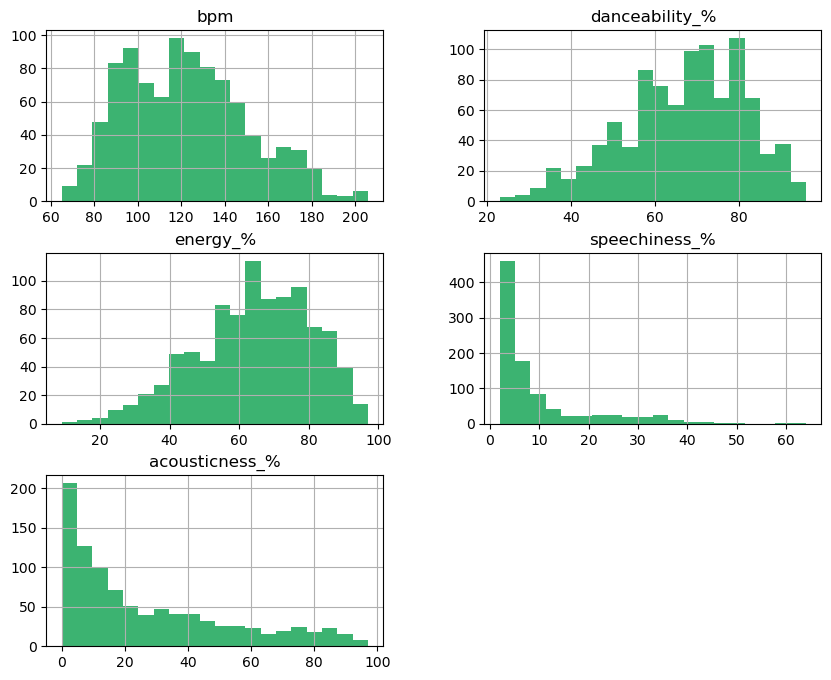

In [4]:
quant_features = ['bpm', 'danceability_%', 'energy_%', 'speechiness_%', 'acousticness_%']
df[quant_features].hist(bins=20, figsize=(10, 8), color='mediumseagreen')

In [5]:
engineered_hits = df[
    (df['key'] == 'C#') & (df['mode'] == 'Major') &
    (df['bpm'] >= 100) & (df['bpm'] <= 140) &
    (df['danceability_%'] >= 57) & (df['danceability_%'] <= 78) &
    (df['energy_%'] >= 53) & (df['energy_%'] <= 77) &
    (df['speechiness_%'] >= 4) & (df['speechiness_%'] <= 11) &
    (df['acousticness_%'] >= 6) & (df['acousticness_%'] <= 43)
]

display(engineered_hits[['track_name', 'artist(s)_name', 'streams']])

,track_name,artist(s)_name,streams
518,Need To Know,Doja Cat,1042568408
660,Ginseng Strip 2002,Yung Lean,240769997


In [6]:
blinding_lights = df[df['track_name'] == 'Blinding Lights']
display(blinding_lights[['track_name', 'bpm', 'key', 'mode', 'danceability_%', 'energy_%']])

,track_name,bpm,key,mode,danceability_%,energy_%
55,Blinding Lights,171,C#,Major,50,80
